# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
import matplotlib.pyplot as plt
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
import shap
from shap import Explainer
import gc
import os

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Custom Vocab Class

In [2]:
# SET RANDOM SEEDS FOR REPRODUCIBILITY
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42) if torch.cuda.is_available() else None

class SimpleVocab:
    def __init__(self, counter, min_freq=1, specials=['<pad>', '<unk>']):
        self.itos = list(specials)
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.stoi:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
    
    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi['<unk>'])
    
    def get_itos(self):
        return self.itos
    
    def __len__(self):
        return len(self.itos)

# Load the dataset


In [3]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [4]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [5]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [6]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [9]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


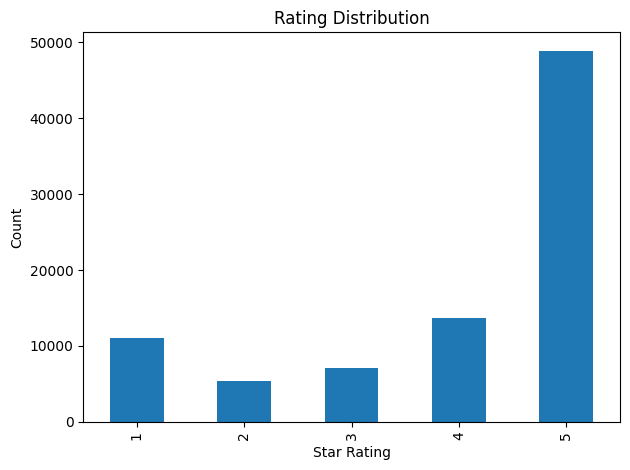

<Figure size 640x480 with 0 Axes>

In [10]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

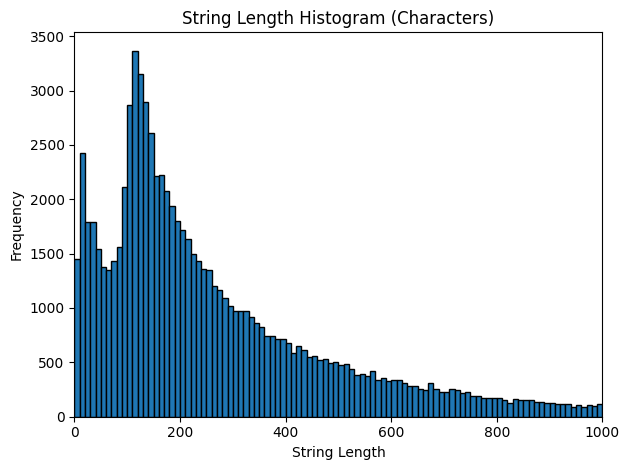

<Figure size 640x480 with 0 Axes>

In [11]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

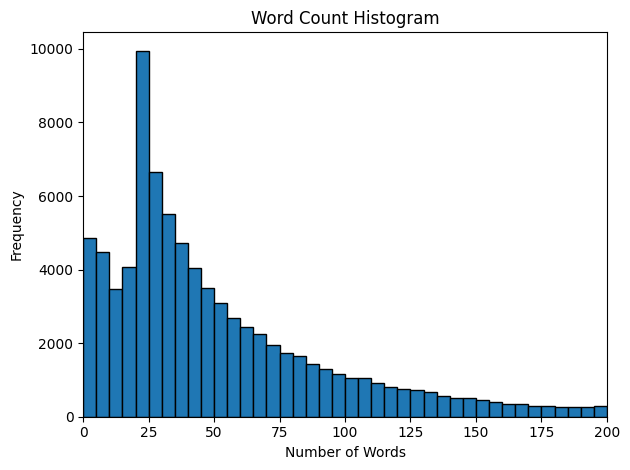

<Figure size 640x480 with 0 Axes>

In [12]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# Drop rows with missing values


In [13]:
df = df[['star_rating', 'review_body']].dropna()

# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)


In [14]:
df = df[df['star_rating'].isin([1, 2, 3, 4, 5])]
df['label'] = df['star_rating'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))

# Print class distribution


In [15]:
# Label mapping
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Count occurrences in the full dataset
class_counts = np.bincount(df['label'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")

Class Distribution (Full Dataset):
Negative: 16372 samples (19.05%)
Neutral: 7043 samples (8.20%)
Positive: 62509 samples (72.75%)


# 1. Data Preprocessing


In [16]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove emails, URLs, phone numbers
    text = re.sub(r'\S+@\S+', '', text)                    # Remove emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)    # Remove URLs
    text = re.sub(r'\+?\d[\d -]{8,}\d', '', text)          # Remove phone numbers
    
    # Remove emojis and non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Remove repeated characters (e.g., loooove → love)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

df['cleaned_review'] = df['review_body'].apply(clean_text)

# View cleaned data

In [17]:
print("Sample of Cleaned Reviews with Labels:")
df[['star_rating', 'label', 'cleaned_review']].sample(10, random_state=42)

Sample of Cleaned Reviews with Labels:


,star_rating,label,cleaned_review
5058,5,2,love
11872,5,2,great value
49489,4,2,purchased daughter months old suffers ee gerd ...
17382,4,2,used mine heavily one year recently found ratt...
13959,5,2,great product delicious smoothies
81653,2,0,less body fat cute little monitor great youre ...
33026,3,1,without getting crude let say theres isnt bett...
65479,2,0,looking inexpensive sad light sit desk work al...
47134,5,2,three pairs insolia various high heels make th...
65630,4,2,read reviews feel compelled leave one would re...


# 2. Tokenization and vocabulary


In [18]:
def tokenize(text):
    return text.split()

counter = Counter()
for text in df['cleaned_review']:
    counter.update(tokenize(text))

vocab = SimpleVocab(counter, min_freq=2, specials=['<pad>', '<unk>'])

def encode(text):
    return [vocab[token] for token in tokenize(text)]

# 3. Dataset and dataloader


In [19]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = [torch.tensor(encode(text), dtype=torch.long) for text in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def collate_batch(batch):
    texts, labels = zip(*batch)
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=vocab['<pad>'])
    return padded_texts, torch.tensor(labels)

# 4. Split data: 70% train, 20% val, 10% test


In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['cleaned_review'].values, df['label'].values,
    test_size=0.3, random_state=42, stratify=df['label'].values
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

train_dataset = ReviewDataset(X_train, y_train)
val_dataset = ReviewDataset(X_val, y_val)
test_dataset = ReviewDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_batch)


# 5. CNN model


In [21]:
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=vocab['<pad>'])
        self.conv1 = nn.Conv1d(embed_dim, 256, kernel_size=5, padding=2)
        self.dropout1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv1d(256, 128, kernel_size=5, padding=2)
        self.dropout2 = nn.Dropout(0.5)
        self.conv3 = nn.Conv1d(128, 100, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(100, 128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = self.dropout1(x)
        x = torch.relu(self.conv2(x))
        x = self.dropout2(x)
        x = torch.relu(self.conv3(x))
        x = self.pool(x).squeeze(2)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.dropout_fc(x)
        return self.fc3(x)

# 6. Training setup


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNTextClassifier(len(vocab)).to(device)

# Compute weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Use in loss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 7. Train and evaluate


In [23]:
history = {
    'epoch': [], 'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'precision': [], 'recall': [], 'f1': []
}

def compute_metrics(true, pred):
    return {
        'accuracy': accuracy_score(true, pred),
        'precision': precision_score(true, pred, average='macro'),
        'recall': recall_score(true, pred, average='macro'),
        'f1': f1_score(true, pred, average='macro')
    }

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            output = model(texts)
            loss = criterion(output, labels)
            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    metrics = compute_metrics(all_labels, all_preds)
    return total_loss / len(loader), metrics, all_labels, all_preds

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(texts)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.argmax(output, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)
    val_loss, val_metrics, _, _ = evaluate(model, val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_metrics['accuracy'])
    history['precision'].append(val_metrics['precision'])
    history['recall'].append(val_metrics['recall'])
    history['f1'].append(val_metrics['f1'])

    print(f"Epoch {epoch} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, "
          f"F1: {val_metrics['f1']:.4f}")

Epoch 1 - Train Loss: 0.9720, Val Loss: 0.8574, Train Acc: 0.6088, Val Acc: 0.7033, F1: 0.5586
Epoch 2 - Train Loss: 0.8145, Val Loss: 0.8397, Train Acc: 0.7039, Val Acc: 0.6040, F1: 0.5394
Epoch 3 - Train Loss: 0.7455, Val Loss: 0.8119, Train Acc: 0.7229, Val Acc: 0.6326, F1: 0.5567
Epoch 4 - Train Loss: 0.6900, Val Loss: 0.7817, Train Acc: 0.7395, Val Acc: 0.6611, F1: 0.5721
Epoch 5 - Train Loss: 0.6387, Val Loss: 0.7823, Train Acc: 0.7553, Val Acc: 0.7117, F1: 0.5910


# 8. Plot metrics

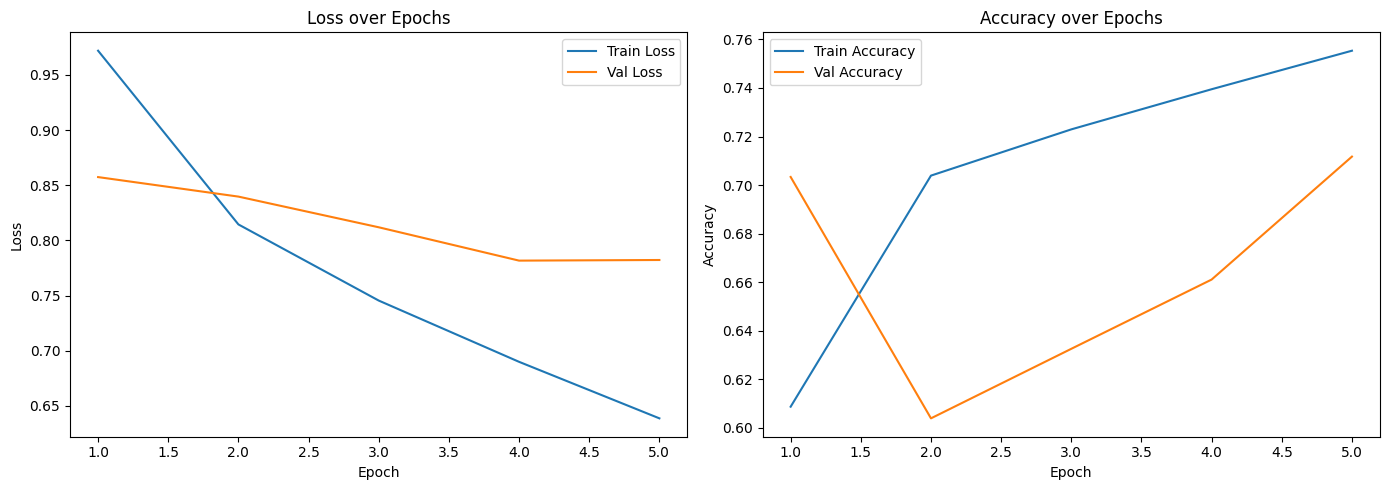

In [24]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
plt.plot(history['epoch'], history['val_loss'], label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss over Epochs"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['epoch'], history['train_acc'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_acc'], label='Val Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy over Epochs"); plt.legend()

plt.tight_layout()
plt.show()

# 9. Final test evaluation and classification report

In [25]:
test_loss, test_metrics, test_labels, test_preds = evaluate(model, test_loader)
print("Final Test Performance:")
print(f"Test Loss: {test_loss:.4f}")
for k, v in test_metrics.items():
    print(f"{k.capitalize()}: {v:.4f}")

print("Classification Report on Test Set:")
print(classification_report(test_labels, test_preds, target_names=["Negative", "Neutral", "Positive"]))

Final Test Performance:
Test Loss: 0.7733
Accuracy: 0.7137
Precision: 0.6293
Recall: 0.6416
F1: 0.5903
Classification Report on Test Set:
              precision    recall  f1-score   support

    Negative       0.76      0.56      0.64      1638
     Neutral       0.18      0.60      0.28       704
    Positive       0.94      0.77      0.85      6251

    accuracy                           0.71      8593
   macro avg       0.63      0.64      0.59      8593
weighted avg       0.84      0.71      0.76      8593



# Plot Test Accuracy by Class

Accuracy Per Class:
  Negative: 0.5562
  Neutral: 0.6009
  Positive: 0.7677


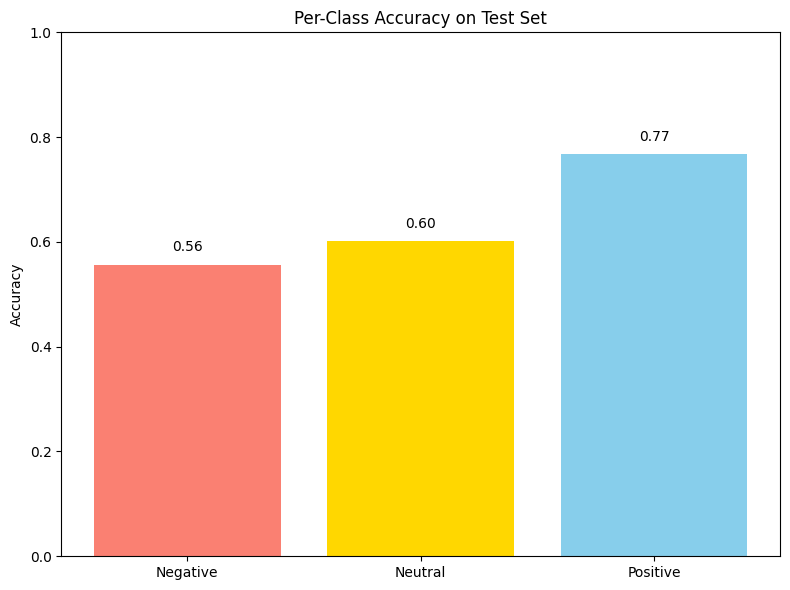

In [26]:
# Calculate per-class accuracy
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)
class_names = ["Negative", "Neutral", "Positive"]
class_accuracies = []

print("Accuracy Per Class:")
for i in range(3):
    class_mask = (test_labels_np == i)
    acc = np.mean(test_preds_np[class_mask] == i)
    class_accuracies.append(acc)
    print(f"  {class_names[i]}: {acc:.4f}")

# Plot accuracy per class
plt.figure(figsize=(8, 6))
bars = plt.bar(class_names, class_accuracies, color=['salmon', 'gold', 'skyblue'])
plt.title("Per-Class Accuracy on Test Set")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
for bar, acc in zip(bars, class_accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{acc:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


# SHAP

# SHAP EXPLAINABILITY ANALYSIS

In [40]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import torch

print("\n" + "="*60)
print("SHAP TOKEN-LEVEL EXPLANATION: CNN MODEL (GLOBAL + LOCAL)")
print("="*60)

# ------------------------------
# 1. Helper: Pad to fixed length
# ------------------------------
MAX_LEN = 100  # or use max(len(encode(x)) for x in X_test_sample[:100])

def pad_encoded_batch(encoded_texts, max_len=MAX_LEN):
    return pad_sequence(
        [torch.tensor(t[:max_len], dtype=torch.long) if len(t) >= max_len 
         else torch.cat([torch.tensor(t, dtype=torch.long), torch.full((max_len - len(t),), vocab['<pad>'])])
         for t in encoded_texts],
        batch_first=True
    )

# ------------------------------
# 2. Prepare data
# ------------------------------
sample_texts = X_test[:100]
sample_labels = y_test[:100]
token_lists = [encode(text) for text in sample_texts]
padded_inputs = pad_encoded_batch(token_lists).to(device)

# ------------------------------
# 3. Define SHAP model wrapper
# ------------------------------
def cnn_predict_tensor(input_array):
    model.eval()
    with torch.no_grad():
        tensor_input = torch.tensor(input_array, dtype=torch.long).to(device)
        outputs = model(tensor_input)
        return torch.softmax(outputs, dim=1).cpu().numpy()

# ------------------------------
# 4. Create SHAP explainer
# ------------------------------
print("Initializing SHAP PermutationExplainer...")
background_tensor = padded_inputs[:50].cpu().numpy()
explainer = shap.Explainer(cnn_predict_tensor, background_tensor, algorithm="permutation")

# ------------------------------
# 5. Compute SHAP values
# ------------------------------
print("Computing SHAP values for 100 test samples...")
shap_values = explainer(padded_inputs[:100].cpu().numpy())  # shape: (samples, tokens, classes)
print("SHAP computation complete!")



SHAP TOKEN-LEVEL EXPLANATION: CNN MODEL (GLOBAL + LOCAL)
Initializing SHAP PermutationExplainer...
Computing SHAP values for 100 test samples...


PermutationExplainer explainer: 101it [00:24,  2.45it/s]                         

SHAP computation complete!


# SHAP VISUALIZATIONS

# Global Explanations

# 1. Summary Bar Plot - Overall Feature Importance for ALL CLASSES


Generating GLOBAL explanation...


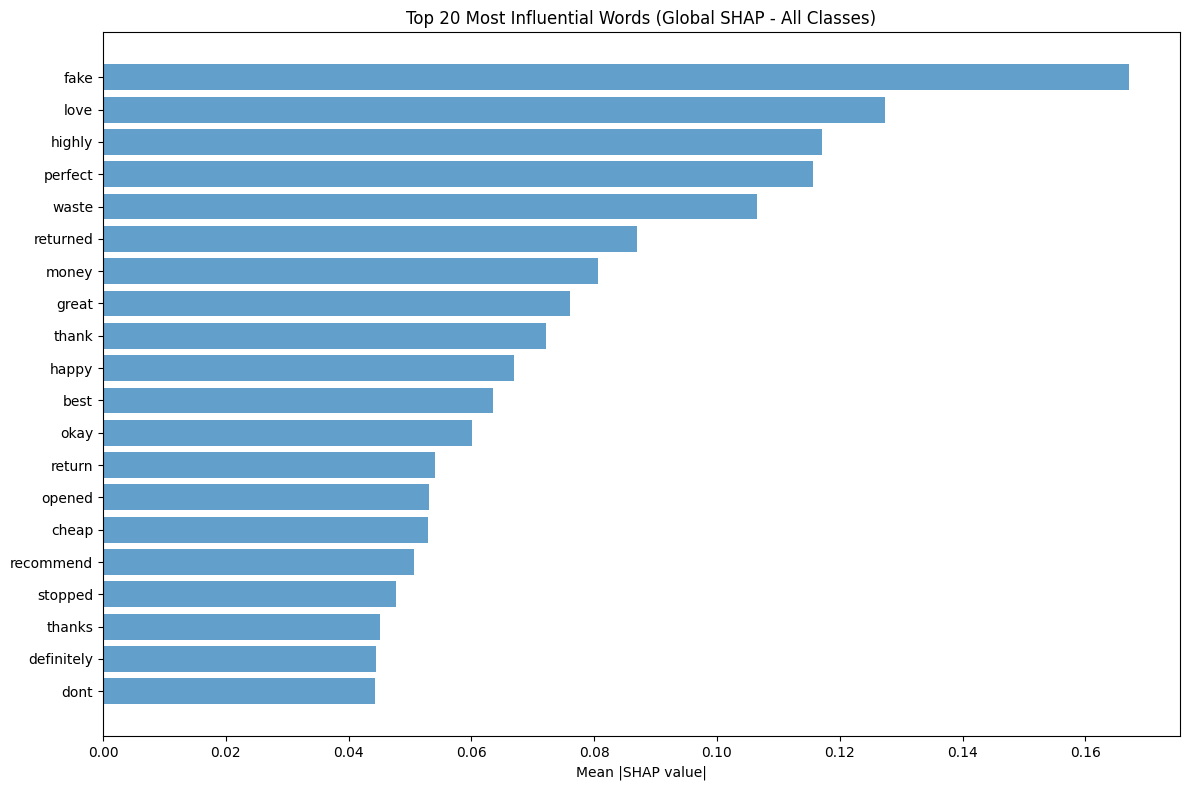

In [41]:
print("\nGenerating GLOBAL explanation...")

word_importance = {}
for i, tokens in enumerate(token_lists[:100]):
    words = tokenize(sample_texts[i])
    for j, tok_id in enumerate(tokens[:MAX_LEN]):
        word = words[j] if j < len(words) else f"[PAD]"
        if word not in word_importance:
            word_importance[word] = []
        word_importance[word].append(np.mean(np.abs(shap_values.values[i, j])))

avg_importance = {word: np.mean(scores) for word, scores in word_importance.items() if len(scores) >= 3}
top_words = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)[:20]

# Plot
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_words))
plt.barh(y_pos, [v for k, v in top_words], alpha=0.7)
plt.yticks(y_pos, [k for k, v in top_words])
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Most Influential Words (Global SHAP - All Classes)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

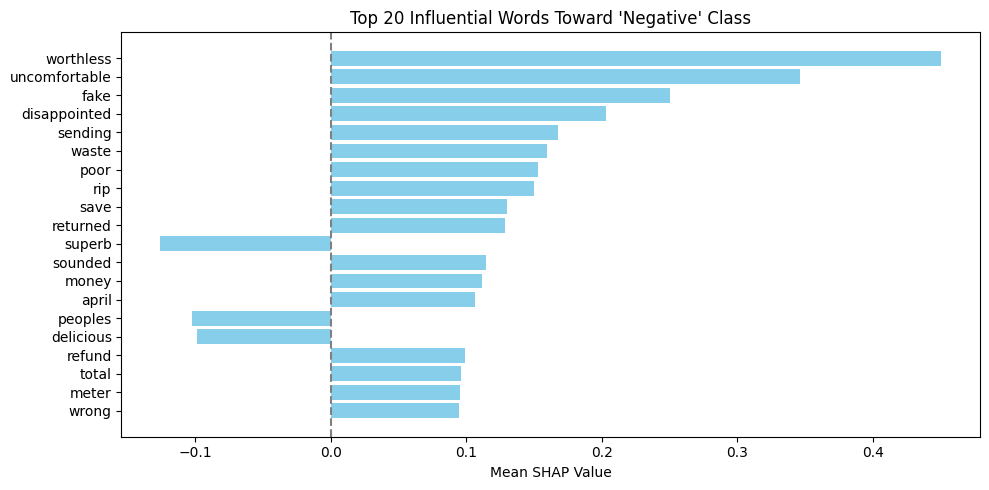

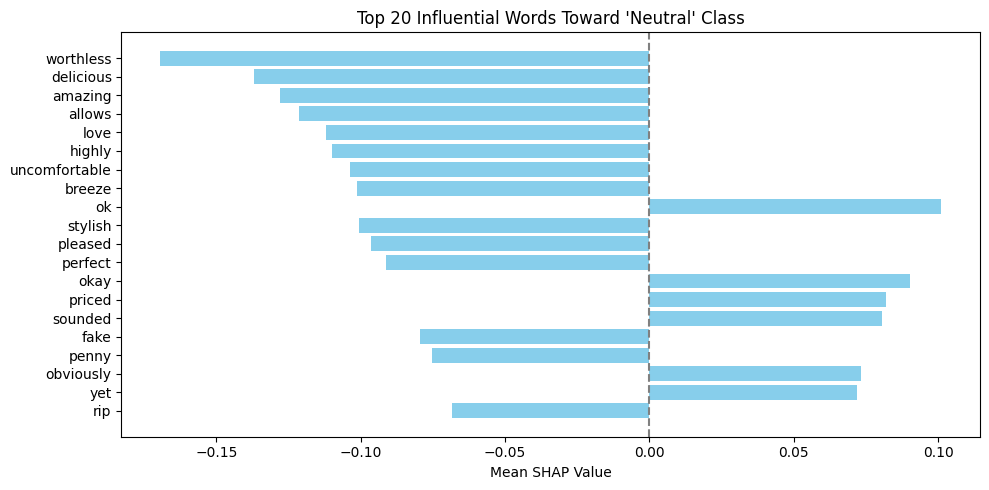

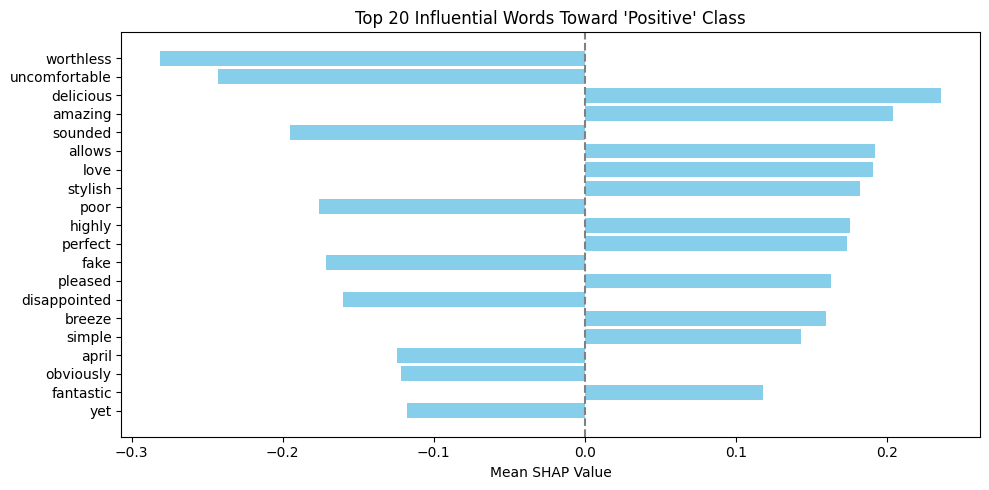

In [70]:
# Initialize dict for each class
class_word_impact = [defaultdict(list) for _ in range(3)]  # assuming 3 classes

for i in range(len(shap_values.values)):  # samples
    for j, token_id in enumerate(padded_inputs[i].cpu().numpy()):
        token = vocab.itos[token_id]
        for c in range(3):  # classes
            class_word_impact[c][token].append(shap_values.values[i, j, c])

# Aggregate: mean SHAP value per token for each class
class_word_avg = [
    {token: np.mean(contribs) for token, contribs in class_dict.items()}
    for class_dict in class_word_impact
]

# Plot for each class
class_names = ['Negative', 'Neutral', 'Positive']
for c in range(3):
    top_words = sorted(class_word_avg[c].items(), key=lambda x: abs(x[1]), reverse=True)[:20]
    words, shap_vals = zip(*top_words)
    
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], shap_vals[::-1], color='skyblue')
    plt.axvline(0, color='gray', linestyle='--')
    plt.title(f"Top 20 Influential Words Toward '{class_names[c]}' Class")
    plt.xlabel("Mean SHAP Value")
    plt.tight_layout()
    plt.show()

# 1b. Summary Plot - Beeswarm style for all classes


✅ Generating SHAP beeswarm plot with color and labels...


The figure layout has changed to tight


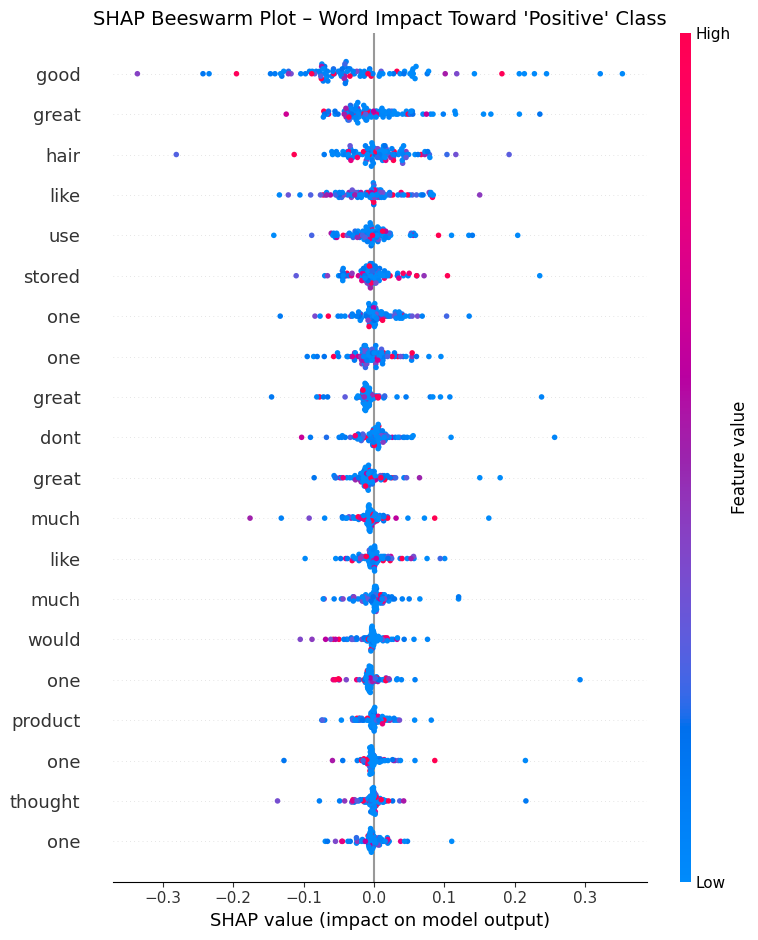

In [56]:
# Step 1: Encode tokens from each sample using vocab
encoded_data = []
decoded_tokens = []

for text in sample_texts[:100]:
    encoded = encode(text)[:MAX_LEN]
    padded_ids = encoded + [vocab['<pad>']] * (MAX_LEN - len(encoded))
    encoded_data.append(padded_ids)

    # Decode tokens for visualization labels
    words = [vocab.itos[tok_id] for tok_id in padded_ids]
    decoded_tokens.append(words)

# Step 2: Convert to NumPy arrays
encoded_data_np = np.array(encoded_data)           # For coloring
decoded_tokens_np = np.array(decoded_tokens)       # For extracting feature names

# Step 3: Set the feature names to the most frequent token at each position
tokens_by_position = decoded_tokens_np.T
feature_names = []

for col_tokens in tokens_by_position:
    counter = Counter([t for t in col_tokens if t != '<pad>'])
    if counter:
        common_word, _ = counter.most_common(1)[0]
    else:
        common_word = '<pad>'
    feature_names.append(common_word)

# Step 4: Create SHAP Explanation with numeric `data` for coloring
expl = shap.Explanation(
    values=shap_values.values[:, :, 2],           # SHAP values for class 2 (Positive)
    base_values=shap_values.base_values[:, 2],    # Base values for class 2
    data=encoded_data_np,                         # Must be numeric for color gradient
    feature_names=feature_names                   # Human-readable labels
)

# Step 5: Plot SHAP beeswarm
print("✅ Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Positive' Class", fontsize=14)
plt.tight_layout()
plt.show()


✅ Generating SHAP beeswarm plot with color and labels...


The figure layout has changed to tight


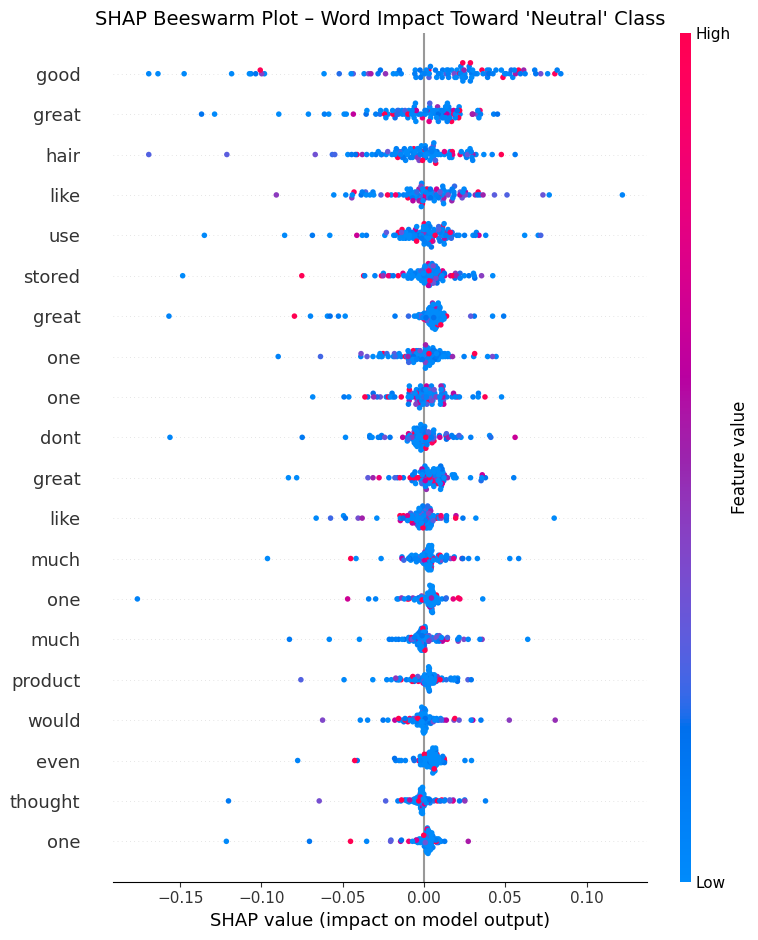

In [58]:
# Step 1: Encode tokens from each sample using vocab
encoded_data = []
decoded_tokens = []

for text in sample_texts[:100]:
    encoded = encode(text)[:MAX_LEN]
    padded_ids = encoded + [vocab['<pad>']] * (MAX_LEN - len(encoded))
    encoded_data.append(padded_ids)

    # Decode tokens for visualization labels
    words = [vocab.itos[tok_id] for tok_id in padded_ids]
    decoded_tokens.append(words)

# Step 2: Convert to NumPy arrays
encoded_data_np = np.array(encoded_data)           # For coloring
decoded_tokens_np = np.array(decoded_tokens)       # For extracting feature names

# Step 3: Set the feature names to the most frequent token at each position
tokens_by_position = decoded_tokens_np.T
feature_names = []

for col_tokens in tokens_by_position:
    counter = Counter([t for t in col_tokens if t != '<pad>'])
    if counter:
        common_word, _ = counter.most_common(1)[0]
    else:
        common_word = '<pad>'
    feature_names.append(common_word)

# Step 4: Create SHAP Explanation with numeric `data` for coloring
expl = shap.Explanation(
    values=shap_values.values[:, :, 1],           # SHAP values for class 2 (Positive)
    base_values=shap_values.base_values[:, 1],    # Base values for class 2
    data=encoded_data_np,                         # Must be numeric for color gradient
    feature_names=feature_names                   # Human-readable labels
)

# Step 5: Plot SHAP beeswarm
print("✅ Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Neutral' Class", fontsize=14)
plt.tight_layout()
plt.show()


 Generating SHAP beeswarm plot with color and labels...


The figure layout has changed to tight


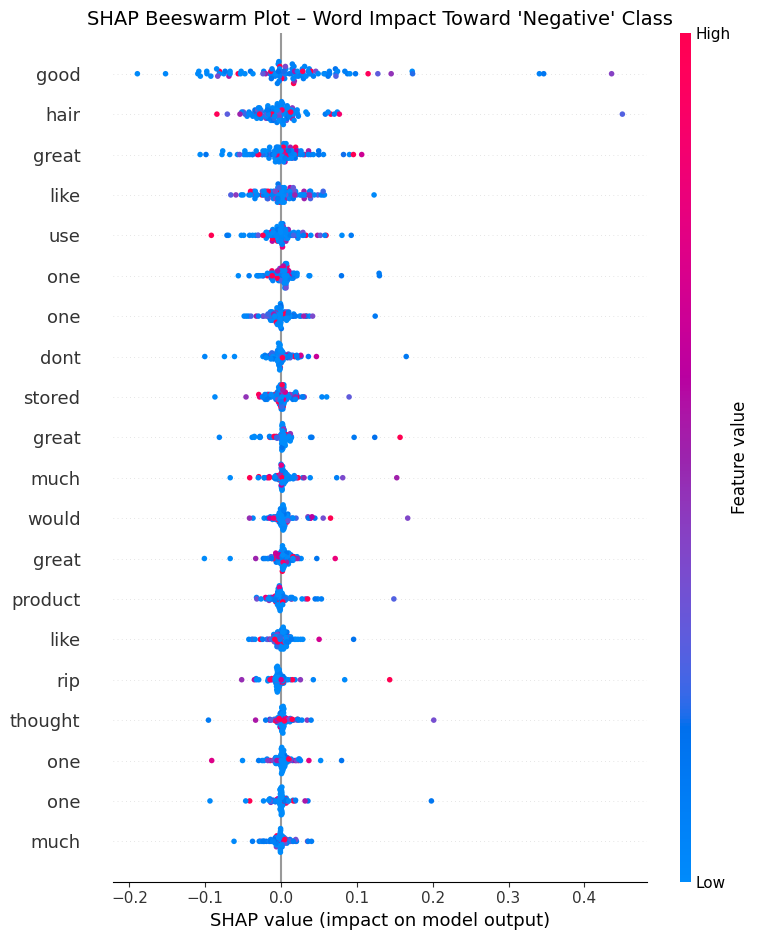

In [57]:
# Step 1: Encode tokens from each sample using vocab
encoded_data = []
decoded_tokens = []

for text in sample_texts[:100]:
    encoded = encode(text)[:MAX_LEN]
    padded_ids = encoded + [vocab['<pad>']] * (MAX_LEN - len(encoded))
    encoded_data.append(padded_ids)

    # Decode tokens for visualization labels
    words = [vocab.itos[tok_id] for tok_id in padded_ids]
    decoded_tokens.append(words)

# Step 2: Convert to NumPy arrays
encoded_data_np = np.array(encoded_data)           # For coloring
decoded_tokens_np = np.array(decoded_tokens)       # For extracting feature names

# Step 3: Set the feature names to the most frequent token at each position
tokens_by_position = decoded_tokens_np.T
feature_names = []

for col_tokens in tokens_by_position:
    counter = Counter([t for t in col_tokens if t != '<pad>'])
    if counter:
        common_word, _ = counter.most_common(1)[0]
    else:
        common_word = '<pad>'
    feature_names.append(common_word)

# Step 4: Create SHAP Explanation with numeric `data` for coloring
expl = shap.Explanation(
    values=shap_values.values[:, :, 0],           # SHAP values for class 2 (Positive)
    base_values=shap_values.base_values[:, 0],    # Base values for class 2
    data=encoded_data_np,                         # Must be numeric for color gradient
    feature_names=feature_names                   # Human-readable labels
)

# Step 5: Plot SHAP beeswarm
print(" Generating SHAP beeswarm plot with color and labels...")
plt.figure(figsize=(12, 8))
shap.summary_plot(expl, max_display=20, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot – Word Impact Toward 'Negative' Class", fontsize=14)
plt.tight_layout()
plt.show()


# 2. Word-Class SHAP Value Heatmap

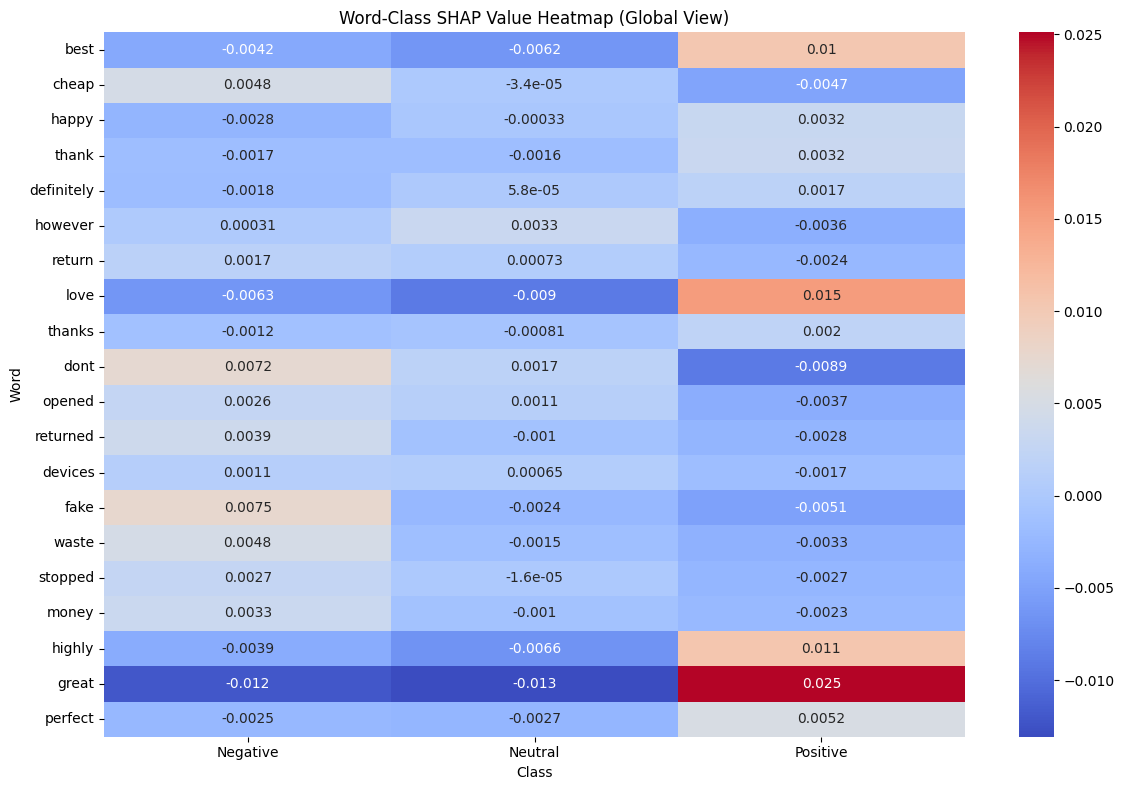

In [46]:
import seaborn as sns

# Top words across all classes
top_words_set = set(k for k, v in top_words)  # use previous top_words

class_matrix = {word: [0.0, 0.0, 0.0] for word in top_words_set}

for i in range(len(sample_texts[:100])):
    tokens = tokenize(sample_texts[i])
    for j, word in enumerate(tokens[:MAX_LEN]):
        if word in class_matrix:
            for c in range(3):
                class_matrix[word][c] += shap_values.values[i, j, c]

# Average them
for word in class_matrix:
    class_matrix[word] = [v / 100 for v in class_matrix[word]]

# Create DataFrame
import pandas as pd
df_heat = pd.DataFrame(class_matrix).T
df_heat.columns = ["Negative", "Neutral", "Positive"]

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(df_heat, annot=True, cmap="coolwarm")
plt.title("Word-Class SHAP Value Heatmap (Global View)")
plt.ylabel("Word")
plt.xlabel("Class")
plt.tight_layout()
plt.show()


# Local Explanations

# 3. Force Plots


In [64]:
print("\nGenerating LOCAL force plots...")

import shap.plots

class_names = ["Negative", "Neutral", "Positive"]
example_indices = []

for label in [0, 1, 2]:
    idx = np.where(sample_labels == label)[0][0]
    example_indices.append(idx)

for i, idx in enumerate(example_indices):
    print(f"\n📌 Example {i+1} - True Class: {class_names[sample_labels[idx]]}")
    print(f"Review: {sample_texts[idx][:120]}...")

    shap_values_sample = shap_values[idx]
    pred = cnn_predict_tensor(np.expand_dims(padded_inputs[idx].cpu().numpy(), axis=0))[0]
    pred_class = np.argmax(pred)

    # Get the original padded input used in SHAP
    token_ids = padded_inputs[idx][:shap_values_sample.values.shape[0]].cpu().numpy()
    tokens_shown = [vocab.itos[token_id] for token_id in token_ids]

    shap.plots.text(shap.Explanation(
        values=shap_values_sample.values[:, pred_class],
        data=tokens_shown,
        base_values=shap_values_sample.base_values[pred_class],
    ))


Generating LOCAL force plots...

📌 Example 1 - True Class: Negative
Review: opened razor brand new box immediately charged full battery life razor could cut anything immediately would shut contact...



📌 Example 2 - True Class: Neutral
Review: purchased april date july longer works came apart springs inside came ibr upset beginning worked okay read somewhat slow...



📌 Example 3 - True Class: Positive
Review: product really works like someone like doesnt wear jewelry lot basic classic styling magnets powerful kind product slips...


In [60]:
print(X_test[:5])  # See if they match the force plot samples


['opened razor brand new box immediately charged full battery life razor could cut anything immediately would shut contact face body rip'
 'purchased april date july longer works came apart springs inside came ibr upset beginning worked okay read somewhat slow ordered another brand havebr one daily use thank'
 'product really works like someone like doesnt wear jewelry lot basic classic styling magnets powerful kind product slips wrist opens easily hey copper soft metal slight squeeze fix wrist without slipping around best thing pain management wrists hands two things going long used alternative medicine type use magnetic field copper ions wear skin worn copper base leave green rings around wrist reaction oils sweat easily washed though need scrub vigorously hope like item also'
 'expected'
 'box torn shreds got though item good condition dont like particular flavor product didnt numb throat dont actually need product know bought party looking good tasting items supply lady friends don

# 4. Waterfall Plots

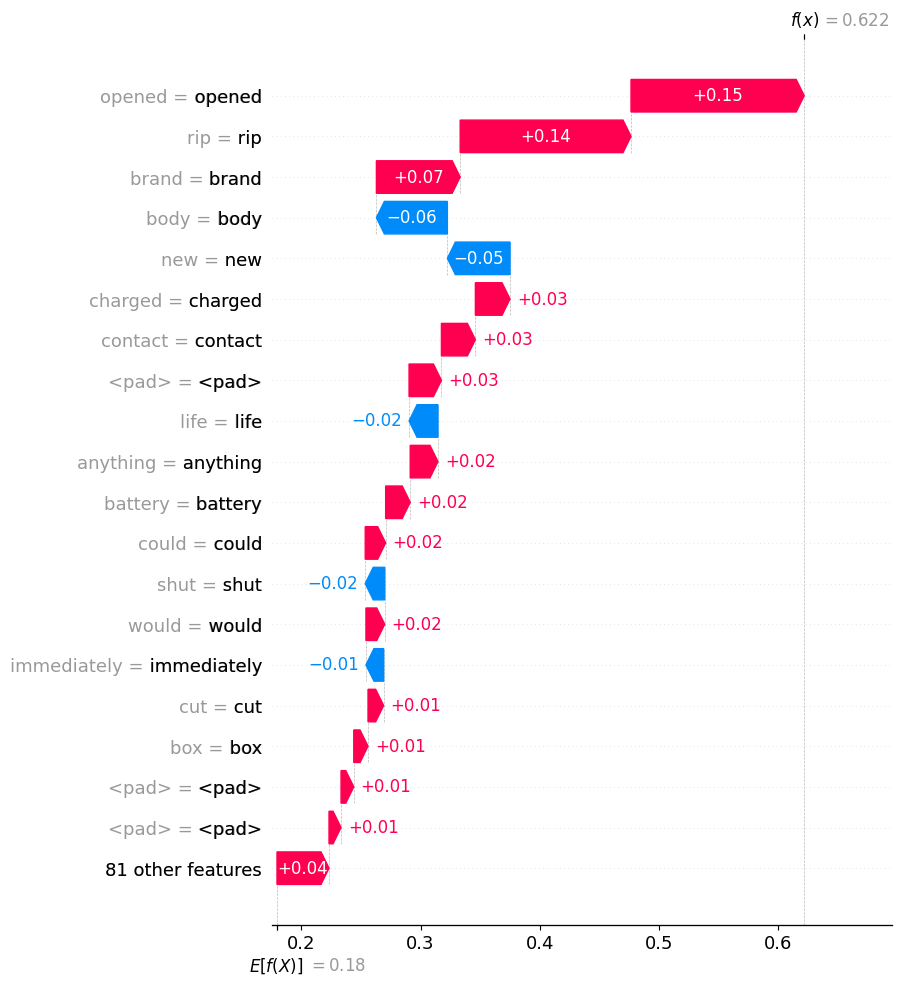

In [65]:
# Example index from your test set
example_idx = 0

# Step 1: Get prediction and SHAP values for one test input
shap_values_sample = shap_values[example_idx]
pred = cnn_predict_tensor(np.expand_dims(padded_inputs[example_idx].cpu().numpy(), axis=0))[0]
pred_class = np.argmax(pred)
base_value = shap_values_sample.base_values[pred_class]
shap_vector = shap_values_sample.values[:, pred_class]

# Step 2: Decode tokens
token_ids = padded_inputs[example_idx][:len(shap_vector)].cpu().numpy()
tokens = [vocab.itos[token_id] for token_id in token_ids]

# Step 3: Create explanation
explanation = shap.Explanation(
    values=shap_vector,
    base_values=base_value,
    data=tokens,
    feature_names=tokens
)

# Step 4: Plot waterfall
shap.plots.waterfall(explanation, max_display=20)


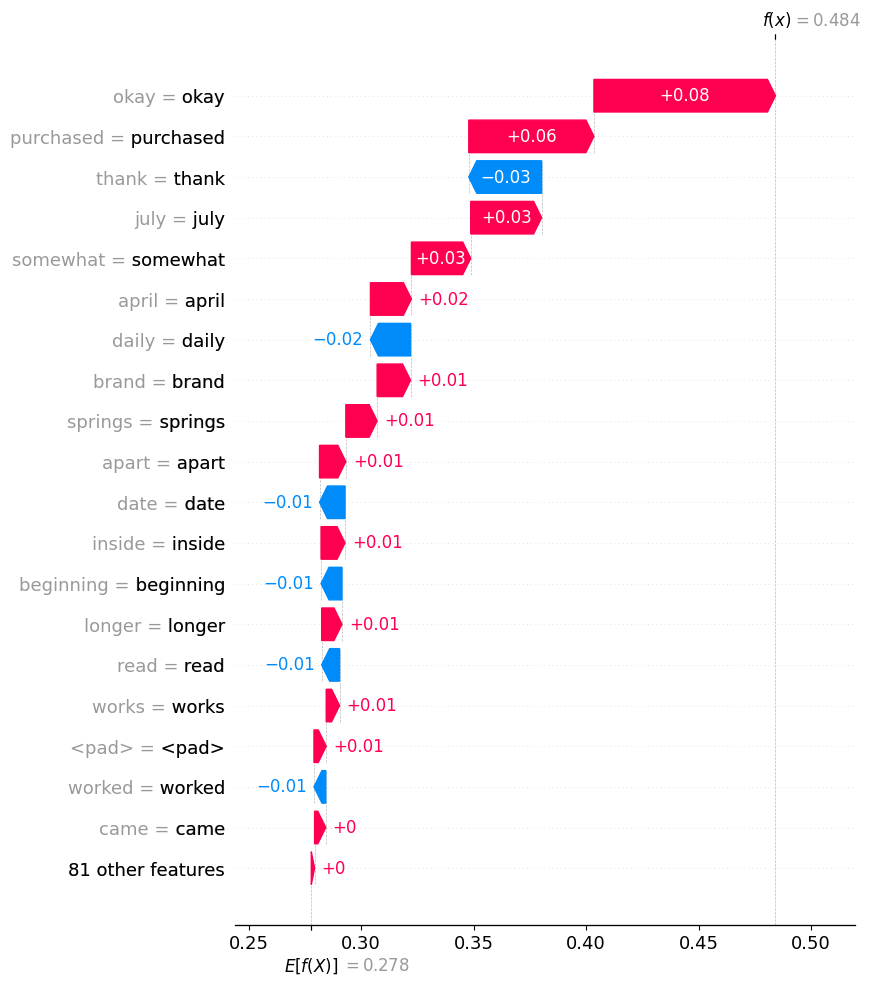

In [66]:
# Example index from your test set
example_idx = 1

# Step 1: Get prediction and SHAP values for one test input
shap_values_sample = shap_values[example_idx]
pred = cnn_predict_tensor(np.expand_dims(padded_inputs[example_idx].cpu().numpy(), axis=0))[0]
pred_class = np.argmax(pred)
base_value = shap_values_sample.base_values[pred_class]
shap_vector = shap_values_sample.values[:, pred_class]

# Step 2: Decode tokens
token_ids = padded_inputs[example_idx][:len(shap_vector)].cpu().numpy()
tokens = [vocab.itos[token_id] for token_id in token_ids]

# Step 3: Create explanation
explanation = shap.Explanation(
    values=shap_vector,
    base_values=base_value,
    data=tokens,
    feature_names=tokens
)

# Step 4: Plot waterfall
shap.plots.waterfall(explanation, max_display=20)


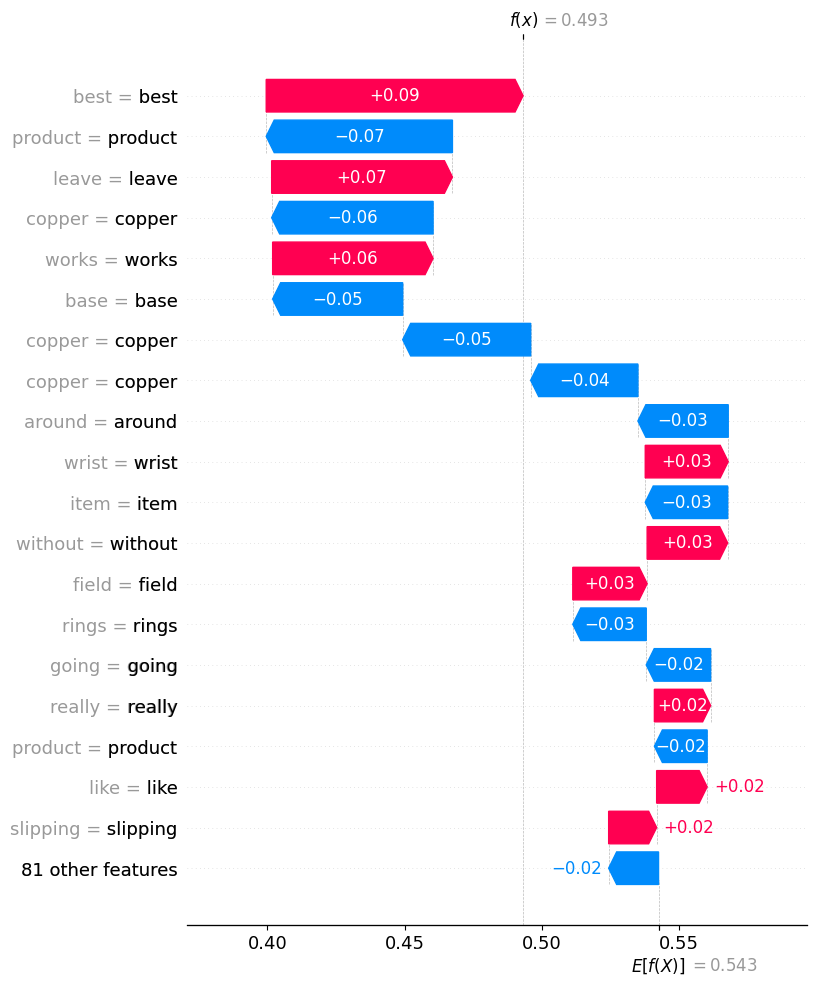

In [67]:
# Example index from your test set
example_idx = 2

# Step 1: Get prediction and SHAP values for one test input
shap_values_sample = shap_values[example_idx]
pred = cnn_predict_tensor(np.expand_dims(padded_inputs[example_idx].cpu().numpy(), axis=0))[0]
pred_class = np.argmax(pred)
base_value = shap_values_sample.base_values[pred_class]
shap_vector = shap_values_sample.values[:, pred_class]

# Step 2: Decode tokens
token_ids = padded_inputs[example_idx][:len(shap_vector)].cpu().numpy()
tokens = [vocab.itos[token_id] for token_id in token_ids]

# Step 3: Create explanation
explanation = shap.Explanation(
    values=shap_vector,
    base_values=base_value,
    data=tokens,
    feature_names=tokens
)

# Step 4: Plot waterfall
shap.plots.waterfall(explanation, max_display=20)
